In [2]:
from archetype_style_analysis import *
from archetype_visualisation import *
from preprocessing import *
import hdbscan
import joblib

Using NumPy backend


2026-06-18 02:00:13.095731: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# We use vgg19_bn instead of vgg19 since it is better
model = models.vgg19_bn(weights=models.VGG19_BN_Weights)
model = model.to(device)
model.eval()
return_nodes = {
    "features.2": "layer1",
    "features.5": "layer2",
    "features.9": "layer3",
    "features.12": "layer4",
    "features.16": "layer5",
}
feature_extractor = create_feature_extractor(model, return_nodes=return_nodes)

/home/mkhales-24/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
all_paths = glob("ArtemisArt/**/*.jpg")
paths = all_paths[::2]
n_archetype = 256
print(f"Il y a {len(paths)} images dans le dataset")

Il y a 7277 images dans le dataset


In [4]:
# def imshow_filter(kernels, row, col):
#     print("-------------------------------------------------------------")
#     plt.figure(figsize=(10, 10))
#     for i in range(len(kernels)):
#         img = np.mean(kernels[i], axis=0)
#         img = img - img.min()
#         img = img / img.max()

#         plt.subplot(row, col, i + 1)
#         plt.imshow(img, cmap="gray")
#         plt.xticks([])
#         plt.yticks([])
#     plt.show()


# conv_layers = []
# for name, module in model.named_modules():
#     if type(module).__name__ == "Conv2d":
#         conv_layers.append(module)

# ### !!!! Attention, y'a vraiment beaucoup d'images qui sont générés donc vaut mieux
# ### sélectionner un layer en particulier !!!!

# for conv in conv_layers:
#     print(conv)
#     kernels = conv.weight.data.cpu().numpy()
#     print(kernels.shape)
#     rows = 8
#     imshow_filter(kernels, rows, kernels.shape[0] // rows)

In [5]:
# def visualize_feature_maps(image_path, extractor, layer_name="layer4", max_features=64):
#     print("-" * 60)
#     img = imread_safe(image_path)

#     preprocess_img = preprocessing_image(img)
#     tensor_img = preprocess_img.to(device)

#     with torch.no_grad():
#         features_dict = extractor(tensor_img)

#     f_map = features_dict[layer_name].squeeze(0).cpu().numpy()

#     print(f"Layer name : {layer_name}")

#     n_features = min(f_map.shape[0], max_features)
#     col = 8
#     row = (n_features + col - 1) // col

#     plt.figure(figsize=(15, 2 * row))

#     for i in range(n_features):
#         activation = f_map[i]

#         activation = activation - activation.min()
#         if activation.max() != 0:
#             activation = activation / activation.max()

#         plt.subplot(row, col, i + 1)
#         plt.imshow(activation, cmap="gray")
#         plt.xticks([])
#         plt.yticks([])

#     plt.tight_layout()
#     plt.show()
#     plt.close()


# img_path = paths[0]
# print(img_path)

# visualize_feature_maps(img_path, feature_extractor, layer_name="layer1")
# visualize_feature_maps(img_path, feature_extractor, layer_name="layer2")
# visualize_feature_maps(img_path, feature_extractor, layer_name="layer3")
# visualize_feature_maps(img_path, feature_extractor, layer_name="layer4")
# visualize_feature_maps(img_path, feature_extractor, layer_name="layer5")

In [6]:
a = ArchetypeGenerator(n_archetype, paths, device, feature_extractor)
A, B, Z, ipca_mod = a.find_archetypes()


Starting transformation of the data...


  0%|          | 0/7277 [00:00<?, ?it/s]

100%|██████████| 7277/7277 [45:05<00:00,  2.69it/s]  


Starting IncrementalPCA fitting...


100%|██████████| 29/29 [20:57<00:00, 43.35s/it]


Starting transformation of the data via IncrementalPCA...


100%|██████████| 29/29 [02:14<00:00,  4.63s/it]


shape of X : (7238, 256)
Starting archetype generation...


In [7]:
visualisation_2d(a.X, Z, a.data_path)

UMAP visualisation done !


In [8]:

donnees_a_sauvegarder = {
    'archetype': a,
    'A': A,
    'B': B,
    'Z': Z,
    'ipca_mod': ipca_mod,
}

joblib.dump(donnees_a_sauvegarder, 'archetypes_data.joblib')
print("a,A,B,Z saved")

a,A,B,Z saved


In [5]:
data = joblib.load('archetypes_data.joblib')

a = data['archetype']
A = data['A']
B = data['B']
Z = data['Z']
ipca_mod = data['ipca_mod']

print("A, B, Z, ipca_mod, scaler loaded")

A, B, Z, ipca_mod, scaler loaded


In [6]:
import umap

Z_2d = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean"
).fit_transform(Z)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=1
)

In [10]:
import umap

Z_2d = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean"
).fit_transform(Z)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=1
)

labels = clusterer.fit_predict(Z_2d) 
unique_clusters = sorted(set(labels))
print(unique_clusters)
for c in unique_clusters:
    if c == -1:
        dirname = "archetypes/noise"
    else:
        dirname = f"archetypes/cluster_{c}"
    os.makedirs(dirname, exist_ok=True)
scaler = None
for i in range(n_archetype):
    image_synthetisee=synthetiser_archetype(
                Z_archetype=Z[i],
                pca_model=ipca_mod,
                extractor=feature_extractor,
                device=device,
                n_iteration=500,
                scaler_model=scaler,
                poids_style=[1.0,1.0,1.0,1.0,1.0]
            )
    plt.imshow(image_synthetisee)
    plt.axis("off")
    plt.title(f"L'essence de l'Archétype {i}")
    plt.savefig(f"archetype_{i}.png", bbox_inches="tight", dpi=300)
    plt.close()
    # Organisation selon les clusters
    cluster_id = labels[i]
    if cluster_id == -1:
        dirname = "archetypes/noise"
    else:
        dirname = f"archetypes/cluster_{cluster_id}"
    plt.imshow(image_synthetisee)
    plt.axis("off")
    plt.savefig(f"{dirname}/archetype_{i}.png", bbox_inches="tight", dpi=300)
    plt.close()
    print(f"Image sauvegardée sous le nom 'archetype_{i}.png' !")

[-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Début de la synthèse (500 itérations, image 224x224, lr=0.01, poids_style=[1.0, 1.0, 1.0, 1.0, 1.0], poids_tv=0.1)...
  Itération 0000 | Style: 1.8683e-01 | TV: 6.6686e-01 | Total: 2.5351e-01
  Itération 0100 | Style: 1.0082e-03 | TV: 5.8572e-02 | Total: 6.8654e-03
  Itération 0200 | Style: 1.2429e-03 | TV: 2.7819e-02 | Total: 4.0249e-03
  Itération 0300 | Style: 1.1090e-03 | TV: 2.6647e-02 | Total: 3.7737e-03
  Itération 0400 | Style: 1.0294e-03 | TV: 2.6269e-02 | Total: 3.6563e-03
Image sauvegardée sous le nom 'archetype_0.png' !
Début de la synthèse (500 itérations, image 224x224, lr=0.01, poids_style=[1.0, 1.0, 1.0, 1.0, 1.0], poids_tv=0.1)...
  Itération 0000 | Style: 2.0948e-01 | TV: 6.6571e-01 | Total: 2.7605e-01
  Itération 0100 | Style: 2.2876e-03 | TV: 4.3640e-02 | Total: 6.6516e-03
  Itération 0200 | Style: 1.8879e-03 | TV: 1.4133e-02 | Total: 3.3012e-03
  Itération 0300 | Style: 1

In [7]:

donnees_a_sauvegarder = {
    'clusterer': clusterer,
}

joblib.dump(donnees_a_sauvegarder, 'clusterer.joblib')
print("clusterer saved")

clusterer saved


In [ ]:
data = joblib.load('clusterer.joblib')

a = data['clusterer']

print("clusterer loaded")

13 archetypes found.
archetypes : [ 21  45  96 143 149 151 154 173 188 190 220 222 235]


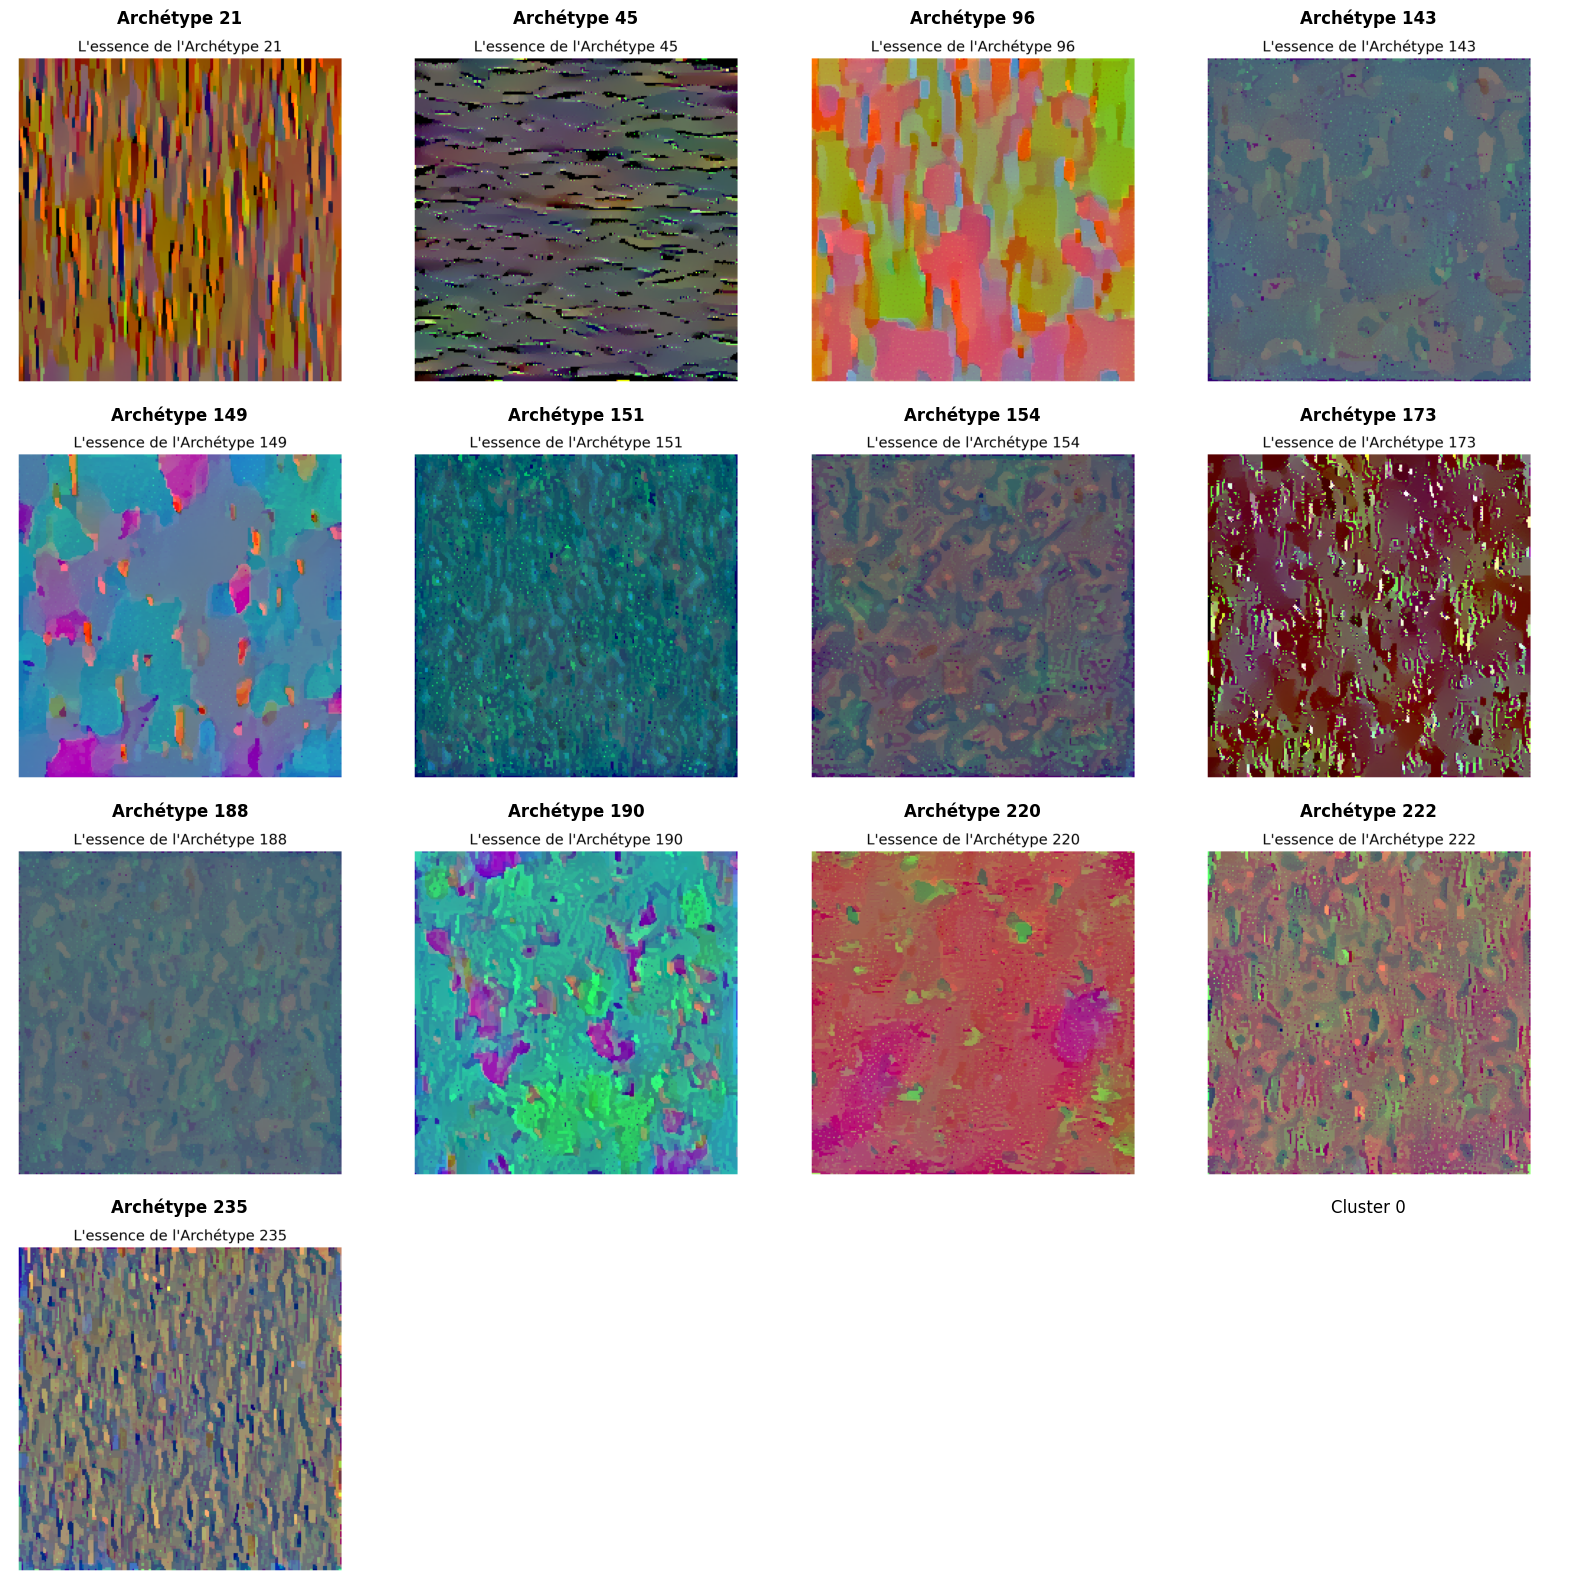

In [ ]:
target_cluster = 0  
indices_in_cluster = np.where(clusterer.labels_ == target_cluster)[0]

print(f"{len(indices_in_cluster)} archetypes found.")
print(f"archetypes : {indices_in_cluster}")

if len(indices_in_cluster) > 0:
    cols = min(4, len(indices_in_cluster))
    rows = (len(indices_in_cluster) + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    if len(indices_in_cluster) == 1:
        axes = np.array([axes])
    if len(axes.shape) == 1:
        axes = np.expand_dims(axes, 0)
    axes = axes.flatten()
    
    for idx, arch_idx in enumerate(indices_in_cluster):
        img_path = f"archetype_{arch_idx}.png"
        
        try:
            img = plt.imread(img_path)
            
            axes[idx].imshow(img)
            axes[idx].set_title(f"Archétype {arch_idx}", fontsize=12, fontweight='bold')
            axes[idx].axis('off')
        except FileNotFoundError:
            axes[idx].text(0.5, 0.5, f"{img_path}\nIntrouvable", ha='center', va='center')
            axes[idx].axis('off')
            
    for idx in range(len(indices_in_cluster), len(axes)):
        axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print(f"No archetypes found: {target_cluster}.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

target_cluster = 0  
max_images = 10     

cluster_paths = a.data_path[clusterer.labels_ == target_cluster]

print(f"Cluster {target_cluster} : {len(cluster_paths)} paintings in total.")

if len(cluster_paths) > 0:
    images_to_show = cluster_paths[:max_images]
    n_images = len(images_to_show)
    
    
    cols = min(5, n_images)
    rows = (n_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
    
    if n_images == 1:
        axes = np.array([axes])
    if len(axes.shape) == 1:
        axes = np.expand_dims(axes, 0)
    axes = axes.flatten()
    
    for idx, path in enumerate(images_to_show):
        img = imread_safe(path)
        img_rgb = img[:, :, ::-1] 
        
        axes[idx].imshow(img_rgb)
        axes[idx].set_title(path.split('/')[-1], fontsize=10)
        axes[idx].axis('off')
        
    for idx in range(n_images, len(axes)):
        axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print(f"No painting found for {target_cluster}.")

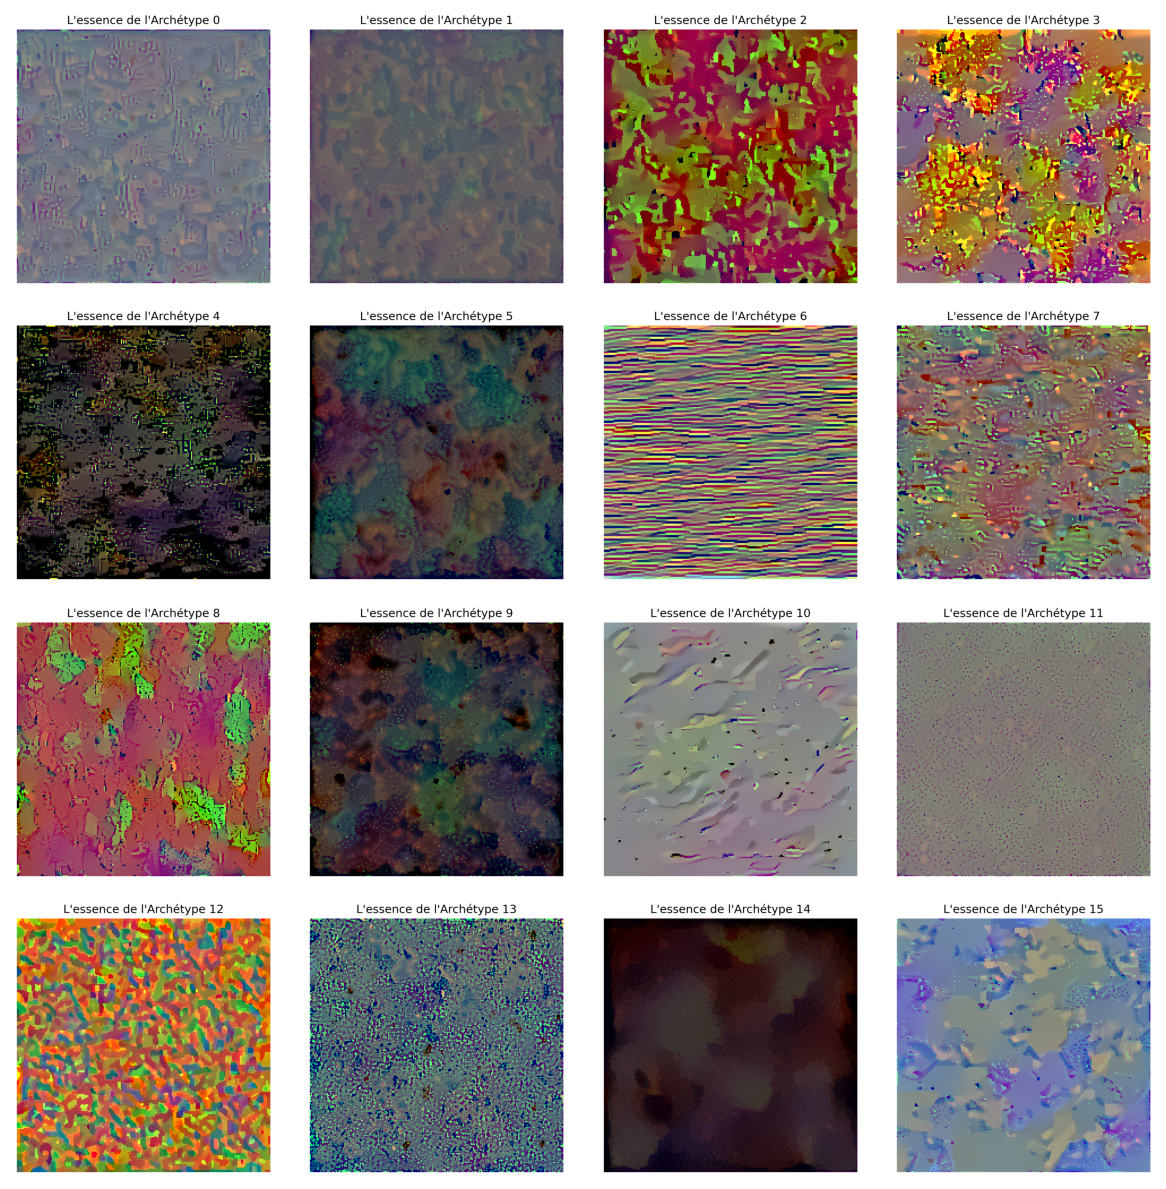

In [11]:
cols = 4
rows = 4

fig, axes = plt.subplots(rows, cols, figsize=(12, 12))

for i in range(16):
    img = imread_safe(f"archetype_{i}.png")
    
    img = img[:, :, ::-1] 
    
    ax = axes[i // cols, i % cols]   # ligne, colonne
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
cols = n_archetype
rows = 5
fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 3*rows))
for i in range(n_archetype):
    L = a.getClosestPaintingsForArchetype(i, 5)
    for k in range(5):
        ax = axes[k,i]
        X_k = imread_safe(L[k])
        ax.imshow(X_k[:, :, ::-1])
        ax.axis("off")
        if k == 0:
            ax.set_title(f"Archetype {i}", fontsize=10)
plt.tight_layout()
plt.show()
        

KeyboardInterrupt: 

In [ ]:
dict = {i: 0 for i in range(15)}
for i in range(n_archetype):
    L = a.getPaintingsFromArchetype(i)
    print(f"For archetype {i}: {L}")
    dict[i] = len(L)

For archetype 0: ['ArtemisArt/monet - claude-monet_1840/monet_103.jpg'
 'ArtemisArt/monet - claude-monet_1840/monet_3.jpg'
 'ArtemisArt/rouault - georges-henri-rouault_1871/rouault_13.jpg' ...
 'ArtemisArt/munch - edvard-munch_1863/munch_21.jpg'
 'ArtemisArt/matisse - henri-matisse_1869/matisse_56.jpg'
 'ArtemisArt/le-greco - domínikos-theotokópoulos_1541/le-greco_16.jpg']
For archetype 1: ['ArtemisArt/de-chazal - malcolm-de-chazal_1902/de-chazal_14.jpg'
 'ArtemisArt/bacon - francis-bacon_1909/bacon_61.jpg'
 'ArtemisArt/vasarely - victor-vasarhelyi-dit-vasarely_1906/vasarely_23.jpg'
 'ArtemisArt/vuillard - edouard-vuillard_1868/vuillard_11.jpg'
 'ArtemisArt/saint-phalle - catherine-de-saint-phalle-dite-niki_1930/saint-phalle_15.jpg'
 'ArtemisArt/baselitz - georg-baselitz_1938/baselitz_8.jpg'
 'ArtemisArt/primitifs-grecs - icones-grece-crete-macedoine-1200-1600_1400/primitifs-grecs_30.jpg'
 'ArtemisArt/signac - paul-signac_1863/signac_25.jpg'
 'ArtemisArt/signac - paul-signac_1863/signa

In [ ]:
import csv
# FAIT PAR IA pour que ce soit plus rapide
path_to_archetype = {}

for i in range(n_archetype):
    L = a.getPaintingsFromArchetype(i)
    for p in L:
        path_to_archetype[p] = i

# 2. Exporter dans l'ordre de paths
with open("paths_archetypes.csv", "w", newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["path", "archetype"])

    for p in paths:
        writer.writerow([p, path_to_archetype.get(p, -1)])
# FIN

{0: 1039, 1: 223, 2: 13, 3: 706, 4: 958, 5: 274, 6: 420, 7: 753, 8: 52, 9: 137, 10: 71, 11: 7, 12: 420, 13: 1082, 14: 1120, 15: 109}


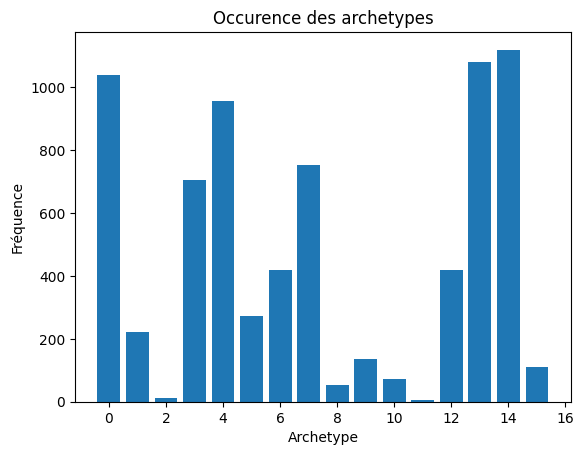

In [ ]:
print(dict)

keys = list(dict.keys())
values = list(dict.values())

plt.bar(keys, values)
plt.xlabel("Archetype")
plt.ylabel("Fréquence")
plt.title("Occurence des archetypes")
plt.show()


9:[0, 9, 21, 104, 130, 100, 128, 404, 143]
9:[0, 4, 9, 18, 25, 8, 18, 74, 67]
9:[0, 0, 0, 0, 0, 0, 0, 6, 7]
9:[1, 9, 18, 80, 70, 51, 80, 273, 124]
9:[1, 9, 19, 87, 115, 111, 144, 343, 129]
9:[1, 3, 12, 28, 23, 9, 19, 100, 79]
9:[0, 5, 14, 29, 30, 26, 38, 163, 115]
9:[0, 8, 18, 96, 104, 78, 91, 250, 108]
9:[0, 0, 1, 4, 0, 1, 3, 25, 18]
9:[1, 0, 4, 17, 24, 4, 8, 45, 34]
9:[0, 0, 3, 6, 2, 1, 3, 32, 24]
9:[0, 0, 1, 0, 0, 0, 0, 2, 4]
9:[2, 11, 15, 50, 45, 30, 36, 136, 95]
9:[0, 11, 27, 123, 155, 112, 138, 372, 144]
9:[2, 12, 20, 102, 129, 109, 153, 436, 157]
9:[0, 1, 5, 7, 5, 4, 7, 38, 42]


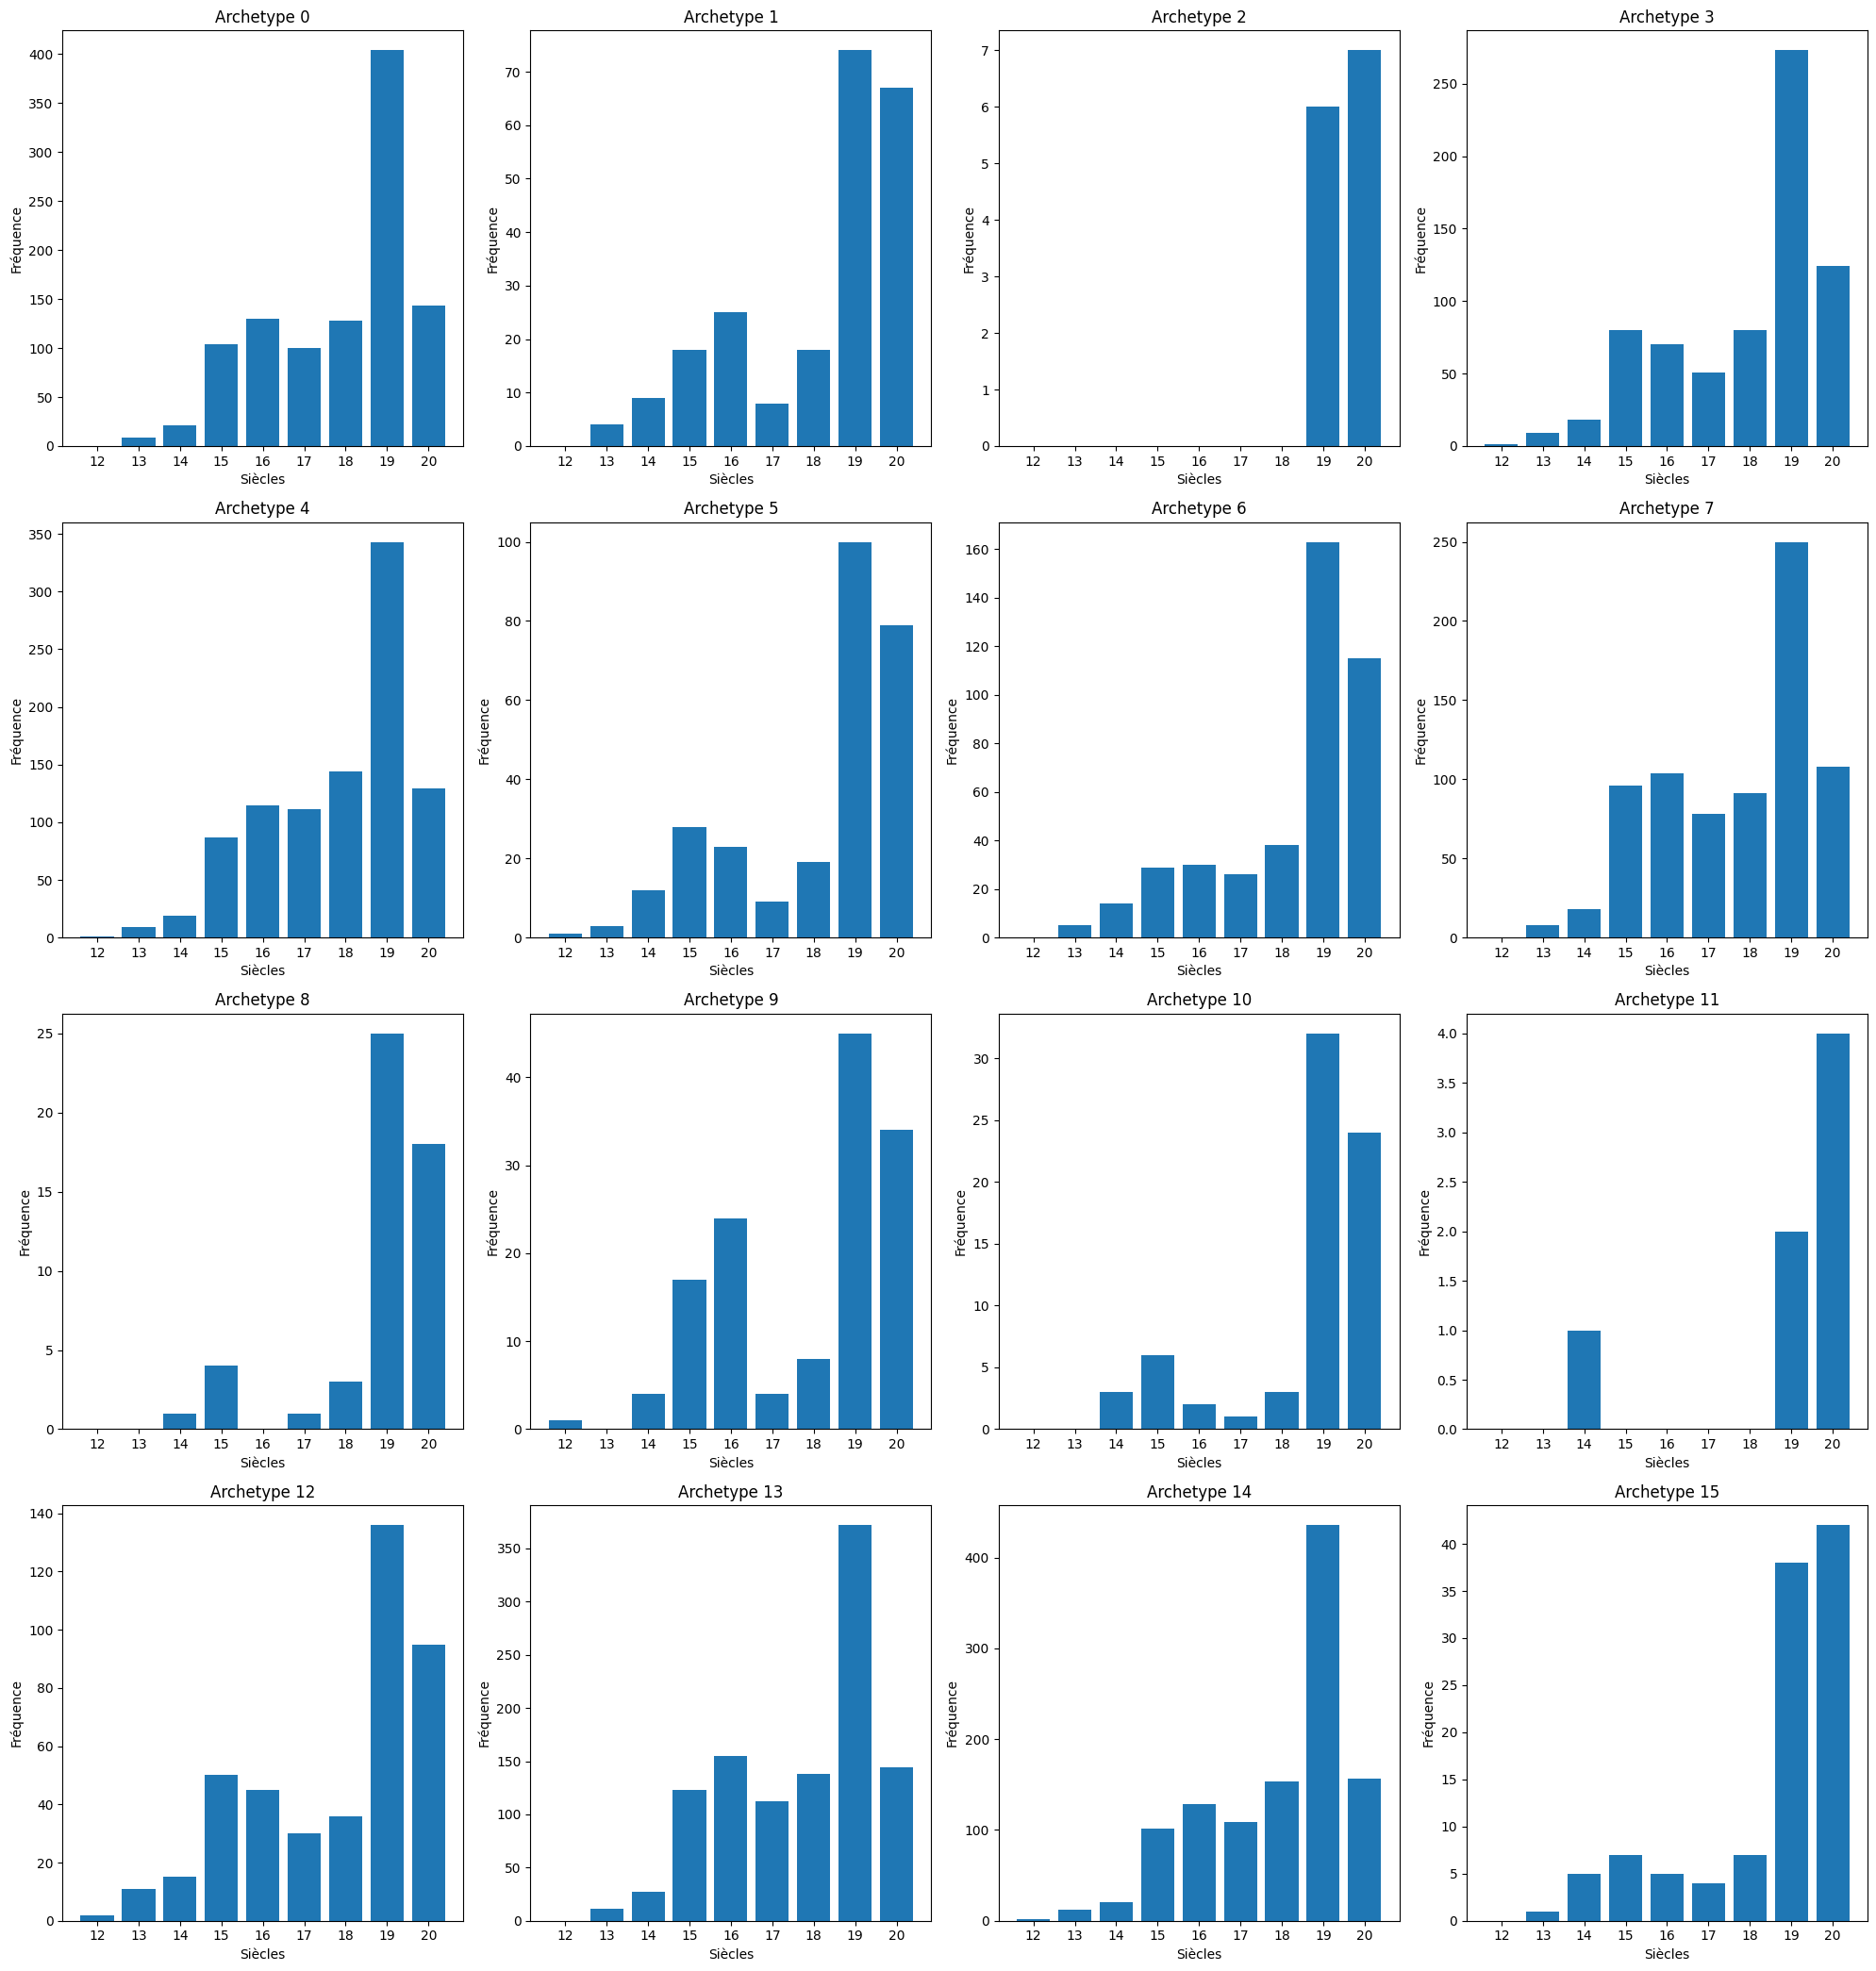

In [ ]:
import re

def extract_year(path):
    match = re.search(r'_(\d{3,4})', path)
    if match :
        return int(match.group(1)) 
    else:
        match = re.search(r'-(\d{3,4})', path)
        return int(match.group(1)) 
    
def year_to_century(path):
    year = extract_year(path)
    return (year - 1) // 100 + 1
inds = [i for i in range(12, 21)]

distrib = []
cols = 4
rows = (n_archetype + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows+5))
axes = axes.flatten()
for i in range(n_archetype):
    siecles_i = {}
    L = a.getPaintingsFromArchetype(i)
    for k in range(len(L)):
        century=year_to_century(L[k])
        if century not in siecles_i.keys():
            siecles_i[century]=1
        else:
            siecles_i[century]+=1
    values = [siecles_i.get(k, 0) for k in inds]
    distrib.append(values)
    print(f"{len(values)}:{values}")
    ax = axes[i]
    ax.bar(inds, values, width=0.8)
    ax.set_xticks(inds)
    ax.set_xlabel("Siècles")
    ax.set_ylabel("Fréquence")
    ax.set_title(f"Archetype {i}")
plt.tight_layout()
plt.show()
        



1820


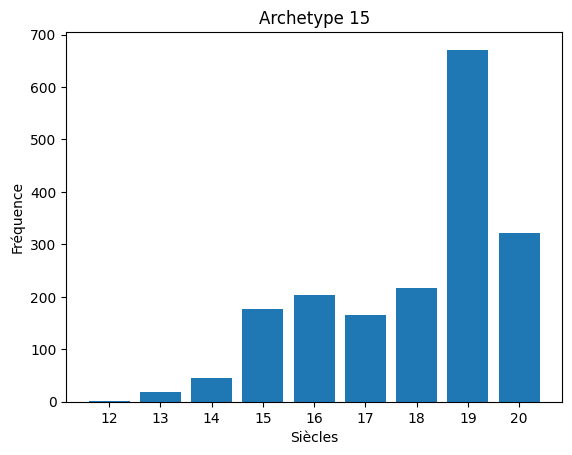

In [ ]:
L = paths
print(len(L))
siecles = {}
for k in range(len(L)):
        century=year_to_century(L[k])
        if century not in siecles.keys():
            siecles[century]=1
        else:
            siecles[century]+=1
keys = sorted(siecles.keys())
values = [siecles.get(k, 0) for k in keys]
plt.bar(keys, values, width=0.8)
plt.xticks(keys)
plt.xlabel("Siècles")
plt.ylabel("Fréquence")
plt.title(f"Archetype {i}")
plt.show()
